In [1]:
import sys

sys.path.insert(0, '/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank/notebook/mylib')
print(sys.path)

['/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank/notebook/mylib', '/group/pmc021/amunif/epi-thesis/workflow/10_Permutation_Test_Ranking/notebook/E066', '/uwahpc/centos8/python/Anaconda3/2024.06/lib/python312.zip', '/uwahpc/centos8/python/Anaconda3/2024.06/lib/python3.12', '/uwahpc/centos8/python/Anaconda3/2024.06/lib/python3.12/lib-dynload', '', '/home/amunif/.local/lib/python3.12/site-packages', '/uwahpc/centos8/python/Anaconda3/2024.06/lib/python3.12/site-packages']


In [2]:
import os
import random
from datetime import datetime

import pandas as pd
import polars as pl
import numpy as np

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, auc, precision_recall_fscore_support, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

import BinaryClassifier as BC
import my_util

In [3]:
WORKING_DIR = '/group/pmc021/amunif/epi-thesis/workflow/10_Permutation_Test_Ranking/'
DATASET_DIR = "/group/pmc021/amunif/epi-thesis/workflow/07_deepchrome/dataset/E066"

In [4]:
device = my_util.get_device()

Using device: cuda
Current CUDA device: 0
CUDA device name: Tesla P100-SXM2-16GB


In [5]:
# Define file numbering based on the index
def format_file_number(number):
    if number < 10:
        return f"00{number}"
    elif number < 100:
        return f"0{number}"
    else:
        return str(number)

In [6]:
# Custom dataset for E066
class E066Dataset(Dataset):
    def __init__(self, total_samples, features, indexes):
        self.total_samples = total_samples
        self.features = features
        self.indexes = indexes

    def __len__(self):
        return self.total_samples

    def __getitem__(self, idx):
        r1 = random.choice(self.indexes)
        r2 = random.choice(self.indexes)
        
        feature_1 = self.features[r1, 1]
        feature_2 = self.features[r2, 1]
        feature = np.concatenate((feature_1, feature_2), axis=0)
        
        val_1 = self.features[r1, 2]
        val_2 = self.features[r2, 2]

        y = 1 if val_1 > val_2 else 0
        
        return feature, y

In [7]:
# Declare  variables, working directory and dataset directory
MODE = 'E066'
NUM_EPOCHS = 100
START_EPOCH = 0
NUM_ITEMS = 100
BATCH_SIZE = 64
DROPOUT_RATE = 0.2

L1_lambda = 0.005
L2_lambda = 0.001
# L1_lambda = 0.0
# L2_lambda = 0.0

MODEL_MODE = "dol1l2" # regular (reg), dropout (do), dropout + l1l2 (dol1l2)
PREFIX = f"{MODEL_MODE}-{DROPOUT_RATE}"
SUFFIX = f"{NUM_ITEMS}-{NUM_EPOCHS}-{BATCH_SIZE}-{L1_lambda}-{L2_lambda}"

CHECKPOINT_NAME = os.path.join(WORKING_DIR, 'output', MODE, "model", f'{PREFIX}-checkpoint-{SUFFIX}.pt')

TEST_FILE = os.path.join(WORKING_DIR, 'output', MODE, 'test', f"{PREFIX}-test-results-{SUFFIX}.txt")
TRAINING_FILE = os.path.join(WORKING_DIR, 'output', MODE, 'train', f"{PREFIX}-train-validation-metrics-{SUFFIX}.csv")
TEST_RESULT_FILE = os.path.join(WORKING_DIR, 'output', MODE, 'test', f"{PREFIX}-test-metrics-{SUFFIX}.csv")
ROC_FILE = os.path.join(WORKING_DIR, 'output', MODE, 'img', 'roc', f"{PREFIX}-roc-{SUFFIX}.png")
IMAGE_FILE = os.path.join(WORKING_DIR, 'output', MODE, 'img', 'train', f"{PREFIX}-ranking-{SUFFIX}.png")
CM_FILE = os.path.join(WORKING_DIR, 'output', MODE, 'img', 'confusion_matrix', f"{PREFIX}-cm-{SUFFIX}.png")

print(CHECKPOINT_NAME)

/group/pmc021/amunif/epi-thesis/workflow/10_Permutation_Test_Ranking/output/E066/model/dol1l2-0.2-checkpoint-100-100-64-0.005-0.001.pt


In [8]:
# Read the dataset
E066_w_histone_pl = pl.read_parquet(os.path.join(DATASET_DIR, 'E066_w_histone_pl.parquet'))

In [9]:
E066_w_histone_pl

gene_id,H3K4me3,H3K4me3_wc,H3K4me3_len,H3K4me1,H3K4me1_wc,H3K4me1_len,H3K36me3,H3K36me3_wc,H3K36me3_len,H3K9me3,H3K9me3_wc,H3K9me3_len,H3K27me3,H3K27me3_wc,H3K27me3_len,E066,label,all_histone
str,list[f64],u32,u32,list[f64],u32,u32,list[f64],u32,u32,list[f64],u32,u32,list[f64],u32,u32,f64,i64,list[list[f64]]
"""ENSG00000000003""","[0.0, 4.19024, … 0.0]",19,100,"[0.0, 0.0, … 0.0]",9,100,"[3.39243, 0.0, … 0.0]",1,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,73.205,1,"[[0.0, 0.0, … 0.0], [0.0, 4.19024, … 0.0], … [3.39243, 0.0, … 0.0]]"
"""ENSG00000000005""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",2,100,"[0.0, 0.0, … 0.0]",0,100,0.191,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
"""ENSG00000000419""","[0.0, 0.0, … 0.0]",36,100,"[0.0, 0.0, … 0.0]",52,100,"[10.55422, 10.55422, … 0.0]",25,100,"[0.0, 0.0, … 0.0]",2,100,"[0.0, 0.0, … 0.0]",0,100,52.609,1,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [10.55422, 10.55422, … 0.0]]"
"""ENSG00000000457""","[0.0, 0.0, … 0.0]",35,100,"[0.0, 0.0, … 0.0]",35,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,4.733,1,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
"""ENSG00000000460""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[3.0104, 3.0104, … 0.0]",5,100,"[0.0, 0.0, … 0.0]",0,100,0.942,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000259658""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,0.212,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
"""ENSG00000259664""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",5,100,0.0,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
"""ENSG00000259680""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,0.071,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"


In [10]:
# Load train-val-test index dataset
train_idx = pd.read_parquet(os.path.join(DATASET_DIR, 'train_idx.parquet'))["values"].to_list()
val_idx = pd.read_parquet(os.path.join(DATASET_DIR, 'val_idx.parquet'))["values"].to_list()
test_idx = pd.read_parquet(os.path.join(DATASET_DIR, 'test_idx.parquet'))["values"].to_list()

In [11]:
print(len(train_idx))
print(len(val_idx))
print(len(test_idx))

15716
1964
1964


In [12]:
# Load permutation list
permutation_lst = pl.read_parquet(os.path.join(DATASET_DIR, 'permutation.parquet'))["markers_perm"].to_list()

In [13]:
#Permutation sample
START = 300
END = 320
working_perm = permutation_lst[START:END]
working_perm

[['H3K9me3', 'H3K27me3', 'H3K36me3', 'H3K4me1', 'H3K4me3'],
 ['H3K27me3', 'H3K4me3', 'H3K4me1', 'H3K36me3', 'H3K9me3'],
 ['H3K27me3', 'H3K4me3', 'H3K4me1', 'H3K9me3', 'H3K36me3'],
 ['H3K27me3', 'H3K4me3', 'H3K36me3', 'H3K4me1', 'H3K9me3'],
 ['H3K27me3', 'H3K4me3', 'H3K36me3', 'H3K9me3', 'H3K4me1'],
 ['H3K27me3', 'H3K4me3', 'H3K9me3', 'H3K4me1', 'H3K36me3'],
 ['H3K27me3', 'H3K4me3', 'H3K9me3', 'H3K36me3', 'H3K4me1'],
 ['H3K27me3', 'H3K4me1', 'H3K4me3', 'H3K36me3', 'H3K9me3'],
 ['H3K27me3', 'H3K4me1', 'H3K4me3', 'H3K9me3', 'H3K36me3'],
 ['H3K27me3', 'H3K4me1', 'H3K36me3', 'H3K4me3', 'H3K9me3'],
 ['H3K27me3', 'H3K4me1', 'H3K36me3', 'H3K9me3', 'H3K4me3'],
 ['H3K27me3', 'H3K4me1', 'H3K9me3', 'H3K4me3', 'H3K36me3'],
 ['H3K27me3', 'H3K4me1', 'H3K9me3', 'H3K36me3', 'H3K4me3'],
 ['H3K27me3', 'H3K36me3', 'H3K4me3', 'H3K4me1', 'H3K9me3'],
 ['H3K27me3', 'H3K36me3', 'H3K4me3', 'H3K9me3', 'H3K4me1'],
 ['H3K27me3', 'H3K36me3', 'H3K4me1', 'H3K4me3', 'H3K9me3'],
 ['H3K27me3', 'H3K36me3', 'H3K4me1', 'H3

In [14]:
# Building the dataframe based on histone markers
item = working_perm[0]
data_df = E066_w_histone_pl.with_columns(histone=pl.concat_list(item))
data_df

gene_id,H3K4me3,H3K4me3_wc,H3K4me3_len,H3K4me1,H3K4me1_wc,H3K4me1_len,H3K36me3,H3K36me3_wc,H3K36me3_len,H3K9me3,H3K9me3_wc,H3K9me3_len,H3K27me3,H3K27me3_wc,H3K27me3_len,E066,label,all_histone,histone
str,list[f64],u32,u32,list[f64],u32,u32,list[f64],u32,u32,list[f64],u32,u32,list[f64],u32,u32,f64,i64,list[list[f64]],list[f64]
"""ENSG00000000003""","[0.0, 4.19024, … 0.0]",19,100,"[0.0, 0.0, … 0.0]",9,100,"[3.39243, 0.0, … 0.0]",1,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,73.205,1,"[[0.0, 0.0, … 0.0], [0.0, 4.19024, … 0.0], … [3.39243, 0.0, … 0.0]]","[0.0, 0.0, … 0.0]"
"""ENSG00000000005""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",2,100,"[0.0, 0.0, … 0.0]",0,100,0.191,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]","[0.0, 0.0, … 0.0]"
"""ENSG00000000419""","[0.0, 0.0, … 0.0]",36,100,"[0.0, 0.0, … 0.0]",52,100,"[10.55422, 10.55422, … 0.0]",25,100,"[0.0, 0.0, … 0.0]",2,100,"[0.0, 0.0, … 0.0]",0,100,52.609,1,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [10.55422, 10.55422, … 0.0]]","[0.0, 0.0, … 0.0]"
"""ENSG00000000457""","[0.0, 0.0, … 0.0]",35,100,"[0.0, 0.0, … 0.0]",35,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,4.733,1,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]","[0.0, 0.0, … 0.0]"
"""ENSG00000000460""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[3.0104, 3.0104, … 0.0]",5,100,"[0.0, 0.0, … 0.0]",0,100,0.942,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]","[3.0104, 3.0104, … 0.0]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000259658""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,0.212,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]","[0.0, 0.0, … 0.0]"
"""ENSG00000259664""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",5,100,0.0,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]","[0.0, 0.0, … 0.0]"
"""ENSG00000259680""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,0.071,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]","[0.0, 0.0, … 0.0]"


In [15]:
X = data_df["gene_id", "histone", "E066"]
X

gene_id,histone,E066
str,list[f64],f64
"""ENSG00000000003""","[0.0, 0.0, … 0.0]",73.205
"""ENSG00000000005""","[0.0, 0.0, … 0.0]",0.191
"""ENSG00000000419""","[0.0, 0.0, … 0.0]",52.609
"""ENSG00000000457""","[0.0, 0.0, … 0.0]",4.733
"""ENSG00000000460""","[3.0104, 3.0104, … 0.0]",0.942
…,…,…
"""ENSG00000259658""","[0.0, 0.0, … 0.0]",0.212
"""ENSG00000259664""","[0.0, 0.0, … 0.0]",0.0
"""ENSG00000259680""","[0.0, 0.0, … 0.0]",0.071


In [16]:
# Convert to Numpy array
X_np = X.to_numpy()

In [17]:
len(X_np[0][1])

500

In [18]:
NUM_ITEMS = 1000
BATCH_SIZE = 32
INPUT_SIZE = len(X_np[0][1]) * 2 # Two histone marker data from two gene IDs
NUM_EPOCHS = 100
START_EPOCH = 0

In [19]:
# Load the dataset into train, validation, and test
train_dataset = E066Dataset(int(0.8 * NUM_ITEMS), X_np, train_idx)
val_dataset = E066Dataset(int(0.1 * NUM_ITEMS), X_np, val_idx)
test_dataset = E066Dataset(int(0.1 * NUM_ITEMS), X_np, test_idx)

In [20]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

800
100
100


In [21]:
# Define the dataloader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)

In [22]:
# Define classifier model
model = BC.BinaryClassifierDropOutL1L2(input_size=INPUT_SIZE).to(device)

# Define loss function for binary classification
criterion = nn.BCELoss()  # Binary Cross Entropy Loss

# Training loop example
optimizer = optim.SGD(model.parameters(), lr=0.0001, momentum=0.9)

# Define learning rate scheduler
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.1)

In [23]:
print(model)

BinaryClassifierDropOutL1L2(
  (network): Sequential(
    (0): Linear(in_features=1000, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): LeakyReLU(negative_slope=0.1)
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


In [24]:
# Arrays for saving the performance metric
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
train_aucs, val_aucs = [], []
val_precisions = []
val_recalls = []
val_f1_scores = []

In [25]:
# Prepare dataset based on the permutation
INDEX = 5
item = working_perm[INDEX]
item_name = '-'.join(item)
print(item)
print(item_name)

['H3K27me3', 'H3K4me3', 'H3K9me3', 'H3K4me1', 'H3K36me3']
H3K27me3-H3K4me3-H3K9me3-H3K4me1-H3K36me3


In [26]:
FILE_NUMBER = format_file_number(INDEX)
FILE_NUMBER

'005'

In [27]:
IMAGE_FILE = os.path.join(WORKING_DIR, 'output', 'E066', 'img', 'train', f"{FILE_NUMBER}-{item_name}-ranking.png")
TEST_FILE = os.path.join(WORKING_DIR, 'output', 'E066', 'test', f"{FILE_NUMBER}-{item_name}-test-results.txt")
TRAINING_FILE = os.path.join(WORKING_DIR, 'output', 'E066', 'train', f"{FILE_NUMBER}-{item_name}-train-validation-metrics.csv")
TEST_RESULT_FILE = os.path.join(WORKING_DIR, 'output', 'E066', 'test', f"{FILE_NUMBER}-{item_name}-test-metrics.csv")
ROC_FILE = os.path.join(WORKING_DIR, 'output', 'E066', 'img', 'roc', f"{FILE_NUMBER}-{item_name}-roc.png")
CM_FILE = os.path.join(WORKING_DIR, 'output', 'E066', 'img', 'confusion_matrix', f"{FILE_NUMBER}-{item_name}-cm.png")

In [28]:
print(IMAGE_FILE)
print(TEST_FILE)
print(TRAINING_FILE)
print(TEST_RESULT_FILE)
print(ROC_FILE)
print(CM_FILE)

/group/pmc021/amunif/epi-thesis/workflow/10_Permutation_Test_Ranking/output/E066/img/train/005-H3K27me3-H3K4me3-H3K9me3-H3K4me1-H3K36me3-ranking.png
/group/pmc021/amunif/epi-thesis/workflow/10_Permutation_Test_Ranking/output/E066/test/005-H3K27me3-H3K4me3-H3K9me3-H3K4me1-H3K36me3-test-results.txt
/group/pmc021/amunif/epi-thesis/workflow/10_Permutation_Test_Ranking/output/E066/train/005-H3K27me3-H3K4me3-H3K9me3-H3K4me1-H3K36me3-train-validation-metrics.csv
/group/pmc021/amunif/epi-thesis/workflow/10_Permutation_Test_Ranking/output/E066/test/005-H3K27me3-H3K4me3-H3K9me3-H3K4me1-H3K36me3-test-metrics.csv
/group/pmc021/amunif/epi-thesis/workflow/10_Permutation_Test_Ranking/output/E066/img/roc/005-H3K27me3-H3K4me3-H3K9me3-H3K4me1-H3K36me3-roc.png
/group/pmc021/amunif/epi-thesis/workflow/10_Permutation_Test_Ranking/output/E066/img/confusion_matrix/005-H3K27me3-H3K4me3-H3K9me3-H3K4me1-H3K36me3-cm.png


In [29]:
# Training loop
for epoch in range(START_EPOCH, NUM_EPOCHS):
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0
    train_true_labels = []
    train_predicted_labels = []

    # Training phase
    for X_batch, y_batch in train_loader:
        outputs, l1_reg, l2_reg = model(X_batch.to(dtype=torch.float32).to(device))
        loss = criterion(outputs.squeeze(1), y_batch.to(dtype=torch.float32).to(device)) + l1_reg + l2_reg

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Calculate accuracy
        predictions = (outputs.squeeze(1) >= 0.5).long()

        train_loss += loss.item()
        train_correct += (predictions == y_batch.to(device)).sum().item()
        train_total += y_batch.size(0)
        
        train_true_labels.extend(y_batch.cpu().numpy())
        train_predicted_labels.extend(predictions.cpu().numpy())
    
    avg_train_loss = train_loss / len(train_loader)
    train_accuracy = 100 * train_correct / train_total
    train_auc_score = roc_auc_score(train_true_labels, train_predicted_labels)

    train_losses.append(round(avg_train_loss, 4))
    train_accuracies.append(round(train_accuracy, 2))
    train_aucs.append(round(train_auc_score, 2))

    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    val_metric = 0
    val_true_labels = []
    val_predicted_labels = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs, l1_reg, l2_reg = model(X_batch.to(dtype=torch.float32).to(device))
            loss = criterion(outputs.squeeze(1), y_batch.to(dtype=torch.float32).to(device)) + l1_reg + l2_reg
            
            predictions = (outputs.squeeze(1) >= 0.5).long()
            
            val_loss += loss.item()
            val_correct += (predictions == y_batch.to(dtype=torch.float32).to(device)).sum().item()
            val_total += y_batch.size(0)
            val_true_labels.extend(y_batch.cpu().numpy())
            val_predicted_labels.extend(predictions.cpu().numpy())
            
        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = 100 * val_correct / val_total
        val_metric = val_correct / len(val_loader)

        # Calculate precision, recall, and F1-score
        precision, recall, f1_score, _ = precision_recall_fscore_support(
            val_true_labels, 
            val_predicted_labels, 
            average='binary'  # Use macro average for multi-class classification
        )

        val_true_labels = np.array(val_true_labels)
        val_predicted_labels = np.array(val_predicted_labels)
        val_auc_score = roc_auc_score(val_true_labels, val_predicted_labels)

        val_losses.append(round(avg_val_loss, 4))
        val_accuracies.append(round(val_accuracy, 2))
        val_aucs.append(round(val_auc_score, 2))
        val_precisions.append(round(precision, 2))
        val_recalls.append(round(recall, 2))
        val_f1_scores.append(round(f1_score, 2))

    # Adjust learning rate
    scheduler.step(val_loss)

    print(f'Epoch [{epoch+1}/{NUM_EPOCHS}] - '
          f'[TRAIN] Loss: {avg_train_loss:.4f}, Accuracy: {train_accuracy:.2f}%, AUC: {train_auc_score:.2f} '
          f'[VAL] Loss: {avg_val_loss:.4f}, Accuracy: {val_accuracy:.2f}%, '
          f'Precision: {precision:.2f}, Recall: {recall:.2f}, F1-Score: {f1_score:.2f}, '
          f'AUC: {val_auc_score:.2f}')
    
    # # Save the model
    # torch.save({
    #     'epoch': epoch,
    #     'model_state_dict': model.state_dict(),
    #     'optimizer_state_dict': optimizer.state_dict(),
    #     'scheduler': scheduler.state_dict(),
    #     'train_losses': train_losses,
    #     'val_losses': val_losses,
    #     'train_accuracies': train_accuracies,
    #     'val_accuracies': val_accuracies,
    #     'train_aucs': train_aucs,
    #     'val_aucs': val_aucs,
    #     'val_precisions': val_precisions,
    #     'val_recalls': val_recalls,
    #     'val_f1_scores': val_f1_scores,
    # }, CHECKPOINT_NAME)

Epoch [1/100] - [TRAIN] Loss: 0.7095, Accuracy: 47.00%, AUC: 0.47 [VAL] Loss: 0.7018, Accuracy: 55.00%, Precision: 0.58, Recall: 0.70, F1-Score: 0.63, AUC: 0.53
Epoch [2/100] - [TRAIN] Loss: 0.6804, Accuracy: 57.25%, AUC: 0.58 [VAL] Loss: 0.6825, Accuracy: 73.00%, Precision: 0.74, Recall: 0.85, F1-Score: 0.79, AUC: 0.70
Epoch [3/100] - [TRAIN] Loss: 0.6652, Accuracy: 62.00%, AUC: 0.62 [VAL] Loss: 0.6864, Accuracy: 62.00%, Precision: 0.57, Recall: 0.70, F1-Score: 0.63, AUC: 0.63
Epoch [4/100] - [TRAIN] Loss: 0.6402, Accuracy: 66.38%, AUC: 0.66 [VAL] Loss: 0.6476, Accuracy: 69.00%, Precision: 0.68, Recall: 0.77, F1-Score: 0.73, AUC: 0.68
Epoch [5/100] - [TRAIN] Loss: 0.6444, Accuracy: 65.75%, AUC: 0.67 [VAL] Loss: 0.5887, Accuracy: 71.00%, Precision: 0.65, Recall: 0.73, F1-Score: 0.69, AUC: 0.71
Epoch [6/100] - [TRAIN] Loss: 0.6120, Accuracy: 71.62%, AUC: 0.72 [VAL] Loss: 0.6078, Accuracy: 70.00%, Precision: 0.72, Recall: 0.72, F1-Score: 0.72, AUC: 0.70
Epoch [7/100] - [TRAIN] Loss: 0.61

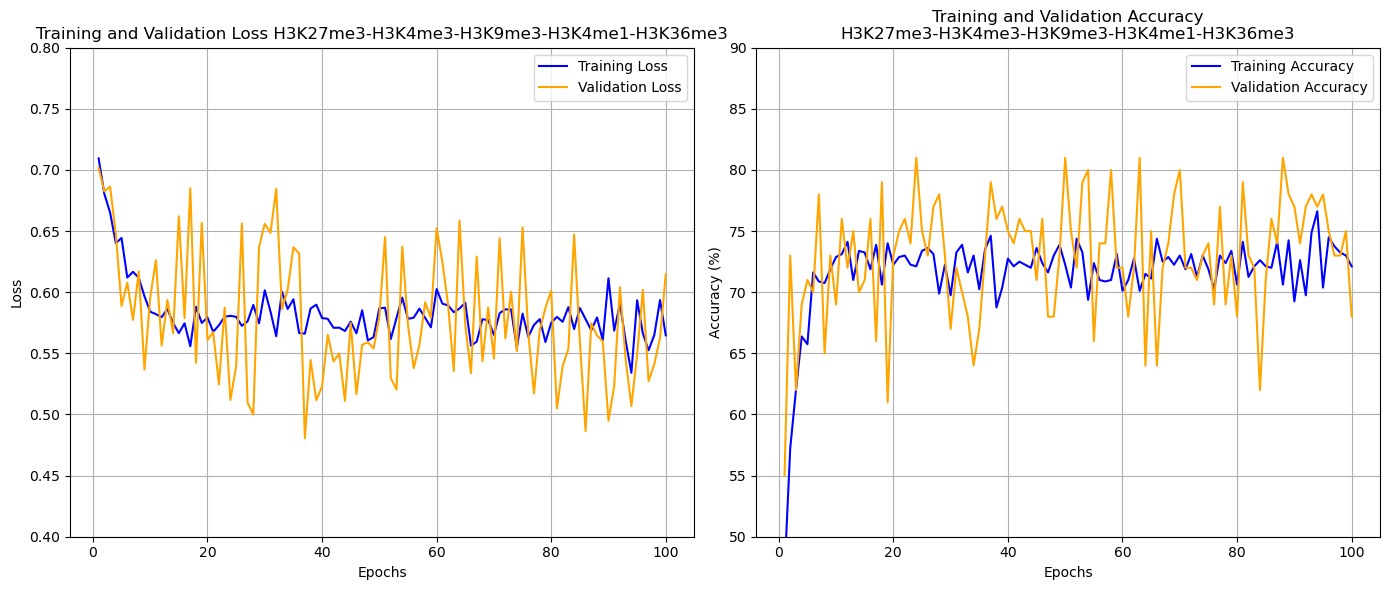

In [30]:
# Plot training and validation metric
my_util.plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies, item_name, NUM_ITEMS, IMAGE_FILE)

In [31]:
# Predict on test set
test_predictions = []
test_true_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs, _, _ = model(X_batch.to(dtype=torch.float32).to(device))
        
        predictions = (outputs.squeeze(1) >= 0.5).long()
        test_true_labels.extend(y_batch.cpu().numpy())
        test_predictions.extend(predictions.cpu().numpy())

In [32]:
# Evaluation metrics
# Precision, Recall, F1-Score
precision, recall, f1_score, _ = precision_recall_fscore_support(
    test_true_labels, 
    test_predictions, 
    average='binary'  # Use 'macro' for multi-class
)

test_acc_score = accuracy_score(test_true_labels, test_predictions) * 100
test_auc_score = roc_auc_score(test_true_labels, test_predictions)
cr = classification_report(test_true_labels, test_predictions)
cm = confusion_matrix(test_true_labels, test_predictions)

In [33]:
test_output = f"""Accuracy Score on test set: {test_acc_score:.2f} %
AUC Score on test set: {test_auc_score:.2f}
Precision: {precision:.4f}
Recall: {recall:.4f}
F1-Score: {f1_score:.4f}

Detailed Classification Report:
{cr}

Confusion Matrix:
{cm}
"""

print(test_output)

Accuracy Score on test set: 76.00 %
AUC Score on test set: 0.76
Precision: 0.7037
Recall: 0.8261
F1-Score: 0.7600

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.70      0.76        54
           1       0.70      0.83      0.76        46

    accuracy                           0.76       100
   macro avg       0.76      0.76      0.76       100
weighted avg       0.77      0.76      0.76       100


Confusion Matrix:
[[38 16]
 [ 8 38]]



In [34]:
# Save the test output to text file
with open(TEST_FILE, 'w', newline = '') as text_file:
    text_file.write(test_output)

In [35]:
# Training metrics
experiment_results = {
    'train_loss'    : train_losses,
    'train_accuracy': train_accuracies,
    'train_auc'     : train_aucs,
    'val_loss'      : val_losses,
    'val_accuracy'  : val_accuracies,
    'val_auc'       : val_aucs
}

experiment_pl = pl.DataFrame(experiment_results)
experiment_pl.write_csv(TRAINING_FILE)

In [36]:
# Get the average for each column
experiment_mean = experiment_pl.mean()
experiment_mean

train_loss,train_accuracy,train_auc,val_loss,val_accuracy,val_auc
f64,f64,f64,f64,f64,f64
0.582901,71.6525,0.7165,0.578792,72.92,0.7286


In [37]:
# Test output
test_results = {
    'histone_marker'     : item_name,
    'train_loss_avg'     : round(experiment_mean["train_loss"][0], 4),
    'train_accuracy_avg' : round(experiment_mean["train_accuracy"][0], 4),
    'train_auc_avg'      : round(experiment_mean["train_auc"][0], 4),
    'val_loss_avg'       : round(experiment_mean["val_loss"][0], 4),
    'val_accuracy_avg'   : round(experiment_mean["val_accuracy"][0], 4),
    'val_auc'            : round(experiment_mean["val_auc"][0], 4),
    'test_acc'           : round(test_acc_score, 4),
    'test_auc'           : round(test_auc_score, 4)
}

test_pl = pl.DataFrame(test_results)
test_pl.write_csv(TEST_RESULT_FILE)

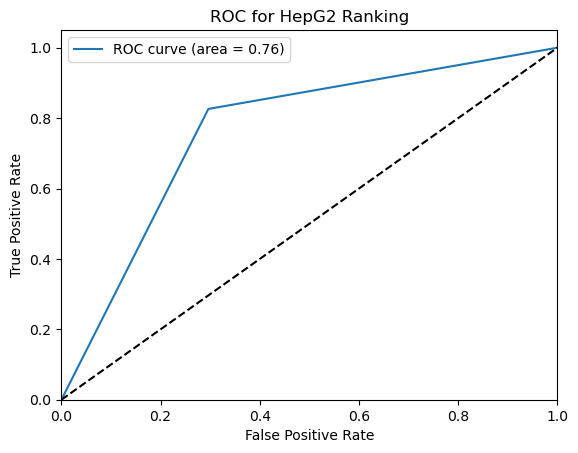

In [38]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_true_labels, test_predictions) 
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure()  
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC for HepG2 Ranking')
plt.legend()

plt.savefig(ROC_FILE)

plt.show()

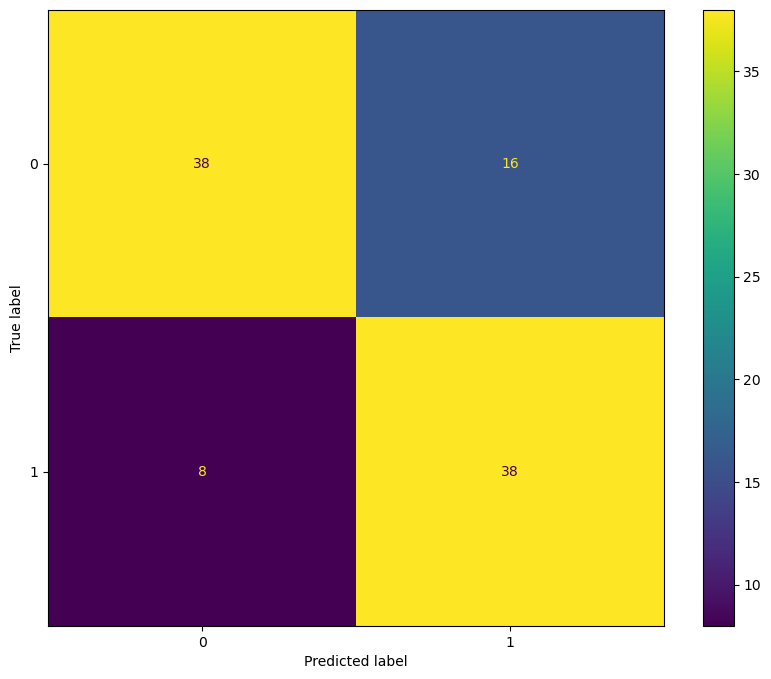

In [39]:
# Plot the confusion matrix
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(10, 8))
cm_display.plot(ax=ax)
plt.savefig(CM_FILE)

In [45]:
START = 0
END = 5
print(START, END)

0 5


In [46]:
working_perm

[['H3K9me3', 'H3K27me3', 'H3K36me3', 'H3K4me1', 'H3K4me3'],
 ['H3K27me3', 'H3K4me3', 'H3K4me1', 'H3K36me3', 'H3K9me3'],
 ['H3K27me3', 'H3K4me3', 'H3K4me1', 'H3K9me3', 'H3K36me3'],
 ['H3K27me3', 'H3K4me3', 'H3K36me3', 'H3K4me1', 'H3K9me3'],
 ['H3K27me3', 'H3K4me3', 'H3K36me3', 'H3K9me3', 'H3K4me1'],
 ['H3K27me3', 'H3K4me3', 'H3K9me3', 'H3K4me1', 'H3K36me3'],
 ['H3K27me3', 'H3K4me3', 'H3K9me3', 'H3K36me3', 'H3K4me1'],
 ['H3K27me3', 'H3K4me1', 'H3K4me3', 'H3K36me3', 'H3K9me3'],
 ['H3K27me3', 'H3K4me1', 'H3K4me3', 'H3K9me3', 'H3K36me3'],
 ['H3K27me3', 'H3K4me1', 'H3K36me3', 'H3K4me3', 'H3K9me3'],
 ['H3K27me3', 'H3K4me1', 'H3K36me3', 'H3K9me3', 'H3K4me3'],
 ['H3K27me3', 'H3K4me1', 'H3K9me3', 'H3K4me3', 'H3K36me3'],
 ['H3K27me3', 'H3K4me1', 'H3K9me3', 'H3K36me3', 'H3K4me3'],
 ['H3K27me3', 'H3K36me3', 'H3K4me3', 'H3K4me1', 'H3K9me3'],
 ['H3K27me3', 'H3K36me3', 'H3K4me3', 'H3K9me3', 'H3K4me1'],
 ['H3K27me3', 'H3K36me3', 'H3K4me1', 'H3K4me3', 'H3K9me3'],
 ['H3K27me3', 'H3K36me3', 'H3K4me1', 'H3

000-H3K9me3-H3K27me3-H3K36me3-H3K4me1-H3K4me3
Epoch [1/100] - [TRAIN] Loss: 0.6998, Accuracy: 53.12%, AUC: 0.52 [VAL] Loss: 0.6519, Accuracy: 65.00%, Precision: 0.80, Recall: 0.40, F1-Score: 0.53, AUC: 0.65
Epoch [2/100] - [TRAIN] Loss: 0.6734, Accuracy: 59.25%, AUC: 0.59 [VAL] Loss: 0.6556, Accuracy: 64.00%, Precision: 0.60, Recall: 0.49, F1-Score: 0.54, AUC: 0.62
Epoch [3/100] - [TRAIN] Loss: 0.6340, Accuracy: 67.62%, AUC: 0.68 [VAL] Loss: 0.6350, Accuracy: 73.00%, Precision: 0.78, Recall: 0.64, F1-Score: 0.70, AUC: 0.73
Epoch [4/100] - [TRAIN] Loss: 0.6242, Accuracy: 66.62%, AUC: 0.67 [VAL] Loss: 0.6568, Accuracy: 67.00%, Precision: 0.80, Recall: 0.59, F1-Score: 0.68, AUC: 0.69
Epoch [5/100] - [TRAIN] Loss: 0.6078, Accuracy: 69.88%, AUC: 0.70 [VAL] Loss: 0.6224, Accuracy: 71.00%, Precision: 0.69, Recall: 0.71, F1-Score: 0.70, AUC: 0.71
Epoch [6/100] - [TRAIN] Loss: 0.6026, Accuracy: 70.00%, AUC: 0.70 [VAL] Loss: 0.5665, Accuracy: 74.00%, Precision: 0.68, Recall: 0.77, F1-Score: 0.72

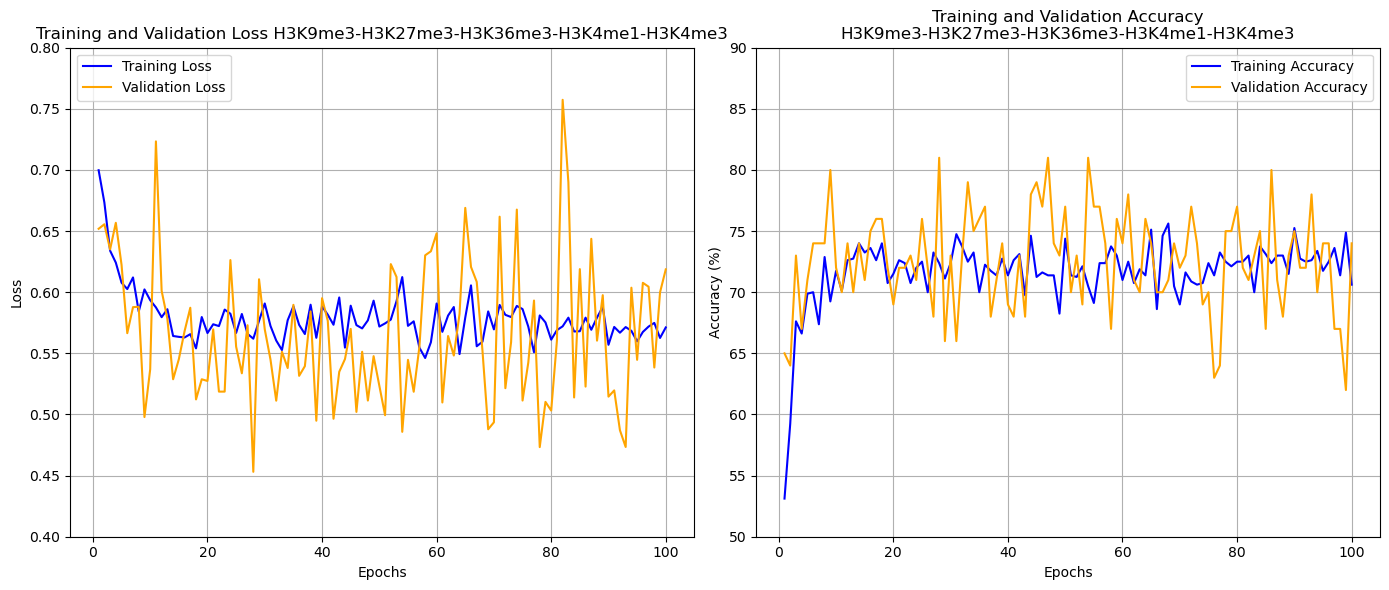

Accuracy Score on test set: 74.00 %
    AUC Score on test set: 0.74
    Precision: 0.7308
    Recall: 0.7600
    F1-Score: 0.7451

    Detailed Classification Report:
                  precision    recall  f1-score   support

           0       0.75      0.72      0.73        50
           1       0.73      0.76      0.75        50

    accuracy                           0.74       100
   macro avg       0.74      0.74      0.74       100
weighted avg       0.74      0.74      0.74       100


    Confusion Matrix:
    [[36 14]
 [12 38]]
    


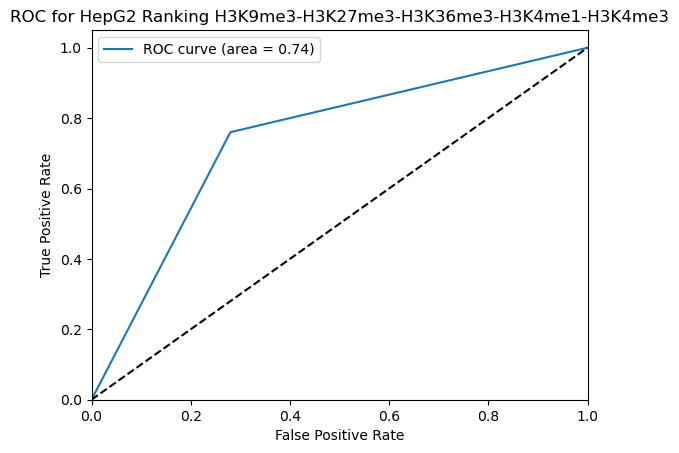

001-H3K27me3-H3K4me3-H3K4me1-H3K36me3-H3K9me3
Epoch [1/100] - [TRAIN] Loss: 0.6891, Accuracy: 55.12%, AUC: 0.55 [VAL] Loss: 0.6870, Accuracy: 55.00%, Precision: 0.65, Recall: 0.37, F1-Score: 0.47, AUC: 0.57
Epoch [2/100] - [TRAIN] Loss: 0.6684, Accuracy: 59.88%, AUC: 0.60 [VAL] Loss: 0.6649, Accuracy: 60.00%, Precision: 0.60, Recall: 0.50, F1-Score: 0.55, AUC: 0.60
Epoch [3/100] - [TRAIN] Loss: 0.6649, Accuracy: 60.38%, AUC: 0.60 [VAL] Loss: 0.6601, Accuracy: 68.00%, Precision: 0.67, Recall: 0.67, F1-Score: 0.67, AUC: 0.68
Epoch [4/100] - [TRAIN] Loss: 0.6342, Accuracy: 67.50%, AUC: 0.67 [VAL] Loss: 0.6575, Accuracy: 67.00%, Precision: 0.76, Recall: 0.61, F1-Score: 0.68, AUC: 0.68
Epoch [5/100] - [TRAIN] Loss: 0.6245, Accuracy: 70.88%, AUC: 0.71 [VAL] Loss: 0.5862, Accuracy: 75.00%, Precision: 0.81, Recall: 0.67, F1-Score: 0.73, AUC: 0.75
Epoch [6/100] - [TRAIN] Loss: 0.6106, Accuracy: 71.88%, AUC: 0.72 [VAL] Loss: 0.5702, Accuracy: 77.00%, Precision: 0.83, Recall: 0.76, F1-Score: 0.79

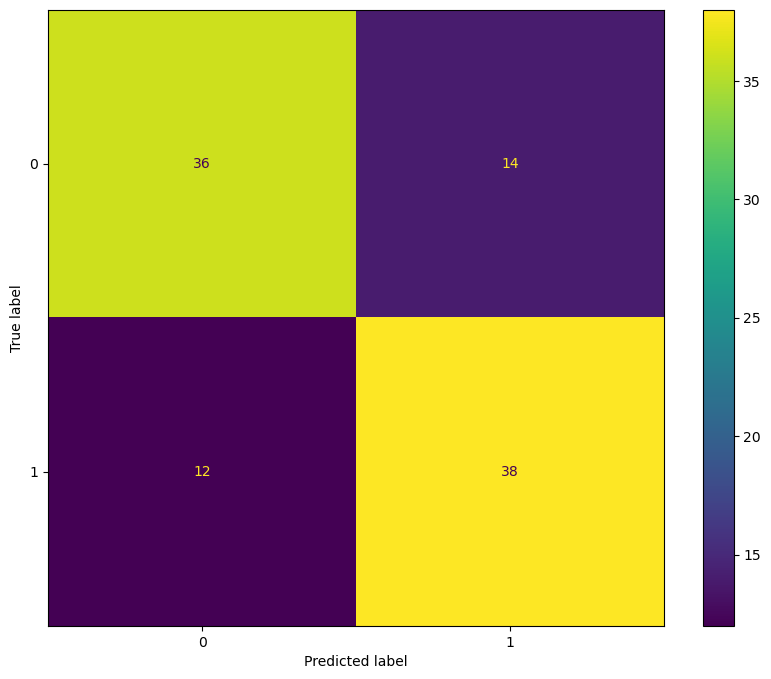

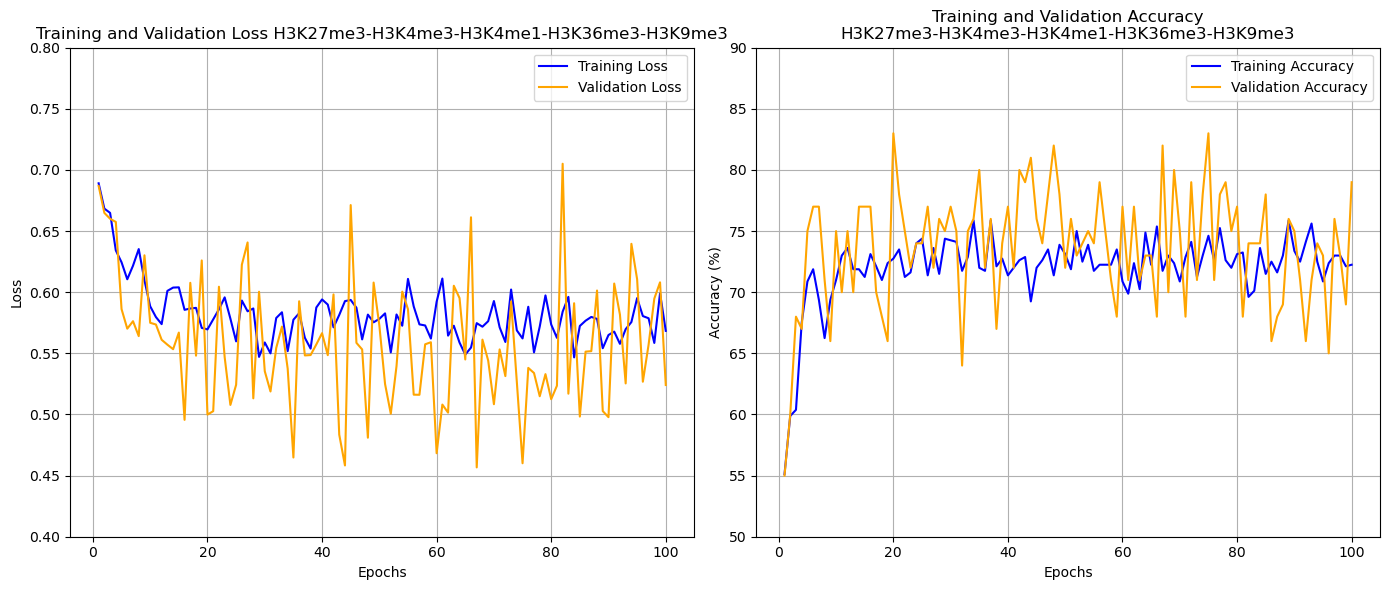

Accuracy Score on test set: 74.00 %
    AUC Score on test set: 0.74
    Precision: 0.6889
    Recall: 0.7209
    F1-Score: 0.7045

    Detailed Classification Report:
                  precision    recall  f1-score   support

           0       0.78      0.75      0.77        57
           1       0.69      0.72      0.70        43

    accuracy                           0.74       100
   macro avg       0.74      0.74      0.74       100
weighted avg       0.74      0.74      0.74       100


    Confusion Matrix:
    [[43 14]
 [12 31]]
    


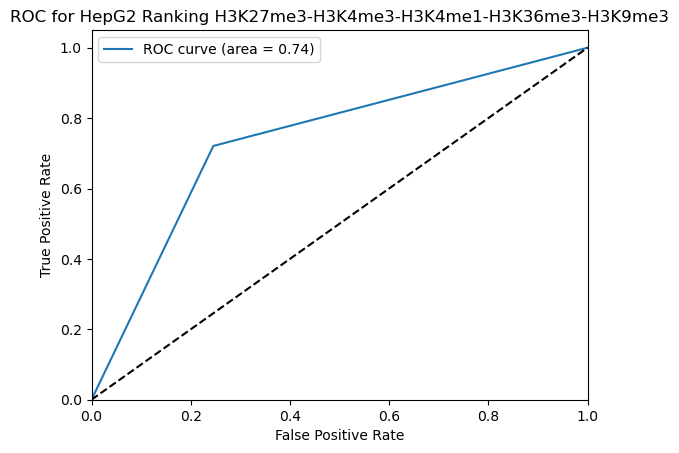

002-H3K27me3-H3K4me3-H3K4me1-H3K9me3-H3K36me3
Epoch [1/100] - [TRAIN] Loss: 0.6473, Accuracy: 66.00%, AUC: 0.66 [VAL] Loss: 0.6406, Accuracy: 70.00%, Precision: 0.77, Recall: 0.63, F1-Score: 0.69, AUC: 0.71
Epoch [2/100] - [TRAIN] Loss: 0.6298, Accuracy: 69.00%, AUC: 0.69 [VAL] Loss: 0.6181, Accuracy: 68.00%, Precision: 0.62, Recall: 0.73, F1-Score: 0.67, AUC: 0.69
Epoch [3/100] - [TRAIN] Loss: 0.6088, Accuracy: 71.25%, AUC: 0.71 [VAL] Loss: 0.5590, Accuracy: 74.00%, Precision: 0.74, Recall: 0.74, F1-Score: 0.74, AUC: 0.74
Epoch [4/100] - [TRAIN] Loss: 0.6102, Accuracy: 69.25%, AUC: 0.69 [VAL] Loss: 0.5413, Accuracy: 75.00%, Precision: 0.70, Recall: 0.78, F1-Score: 0.74, AUC: 0.75
Epoch [5/100] - [TRAIN] Loss: 0.5931, Accuracy: 70.75%, AUC: 0.71 [VAL] Loss: 0.5262, Accuracy: 78.00%, Precision: 0.77, Recall: 0.77, F1-Score: 0.77, AUC: 0.78
Epoch [6/100] - [TRAIN] Loss: 0.5945, Accuracy: 71.88%, AUC: 0.72 [VAL] Loss: 0.6448, Accuracy: 69.00%, Precision: 0.74, Recall: 0.64, F1-Score: 0.69

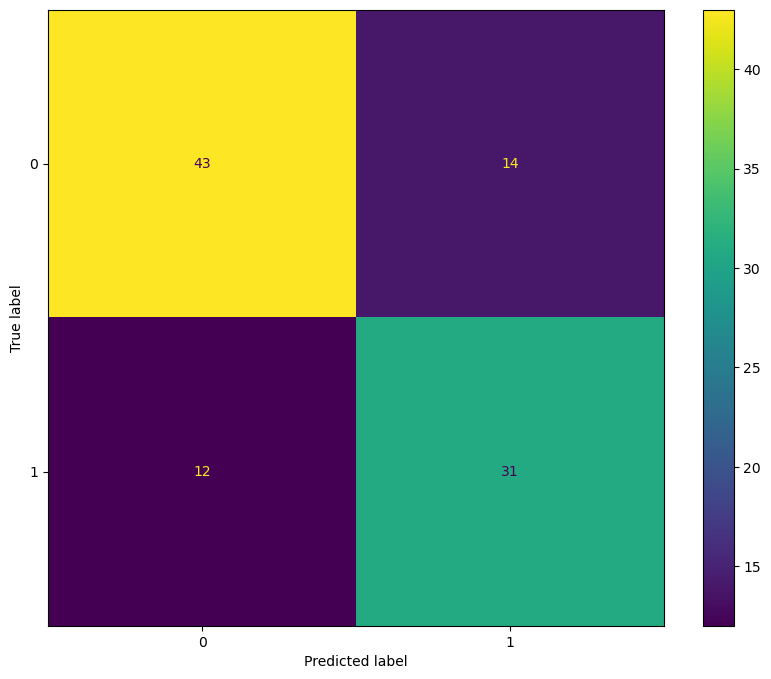

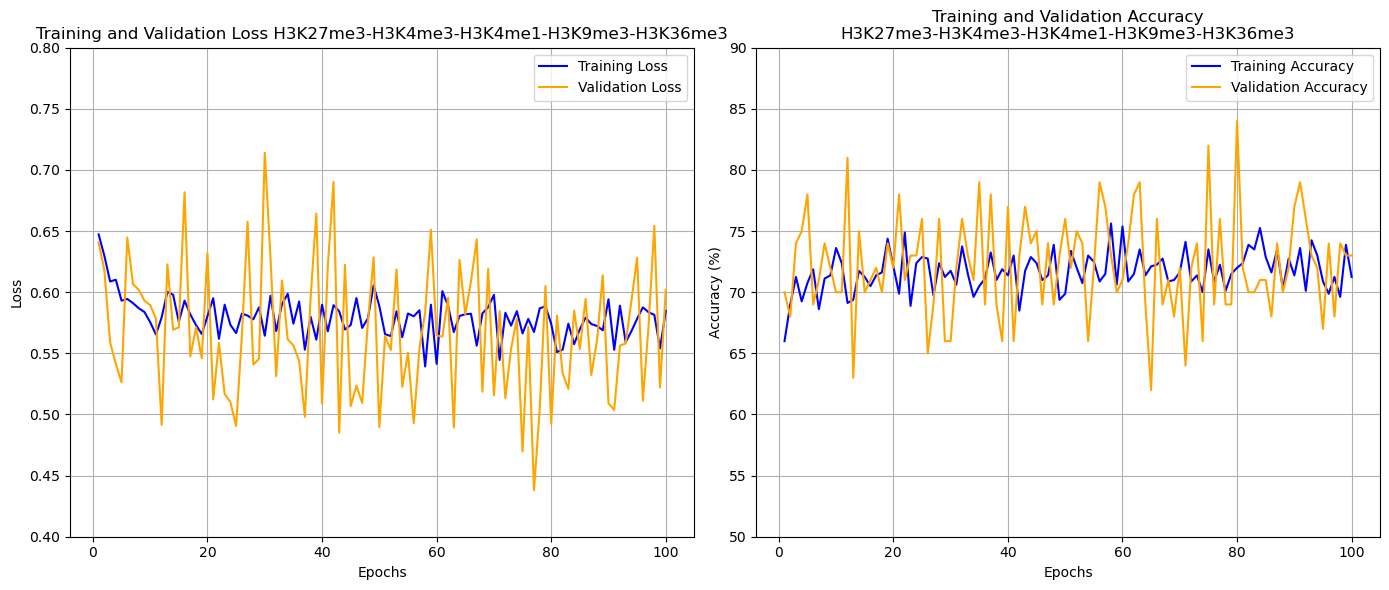

Accuracy Score on test set: 75.00 %
    AUC Score on test set: 0.74
    Precision: 0.7561
    Recall: 0.6739
    F1-Score: 0.7126

    Detailed Classification Report:
                  precision    recall  f1-score   support

           0       0.75      0.81      0.78        54
           1       0.76      0.67      0.71        46

    accuracy                           0.75       100
   macro avg       0.75      0.74      0.75       100
weighted avg       0.75      0.75      0.75       100


    Confusion Matrix:
    [[44 10]
 [15 31]]
    


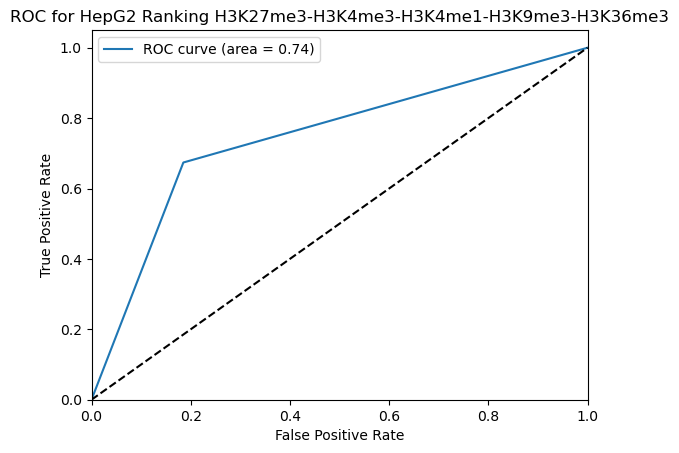

003-H3K27me3-H3K4me3-H3K36me3-H3K4me1-H3K9me3
Epoch [1/100] - [TRAIN] Loss: 0.7257, Accuracy: 49.50%, AUC: 0.48 [VAL] Loss: 0.7419, Accuracy: 51.00%, Precision: 0.51, Recall: 0.98, F1-Score: 0.67, AUC: 0.50
Epoch [2/100] - [TRAIN] Loss: 0.7170, Accuracy: 50.25%, AUC: 0.52 [VAL] Loss: 0.6643, Accuracy: 55.00%, Precision: 0.55, Recall: 0.93, F1-Score: 0.69, AUC: 0.52
Epoch [3/100] - [TRAIN] Loss: 0.6707, Accuracy: 60.00%, AUC: 0.59 [VAL] Loss: 0.6934, Accuracy: 53.00%, Precision: 0.51, Recall: 0.80, F1-Score: 0.62, AUC: 0.54
Epoch [4/100] - [TRAIN] Loss: 0.6535, Accuracy: 62.38%, AUC: 0.62 [VAL] Loss: 0.6307, Accuracy: 64.00%, Precision: 0.61, Recall: 0.84, F1-Score: 0.70, AUC: 0.64
Epoch [5/100] - [TRAIN] Loss: 0.6325, Accuracy: 66.88%, AUC: 0.67 [VAL] Loss: 0.6402, Accuracy: 62.00%, Precision: 0.56, Recall: 0.83, F1-Score: 0.67, AUC: 0.64
Epoch [6/100] - [TRAIN] Loss: 0.6260, Accuracy: 67.38%, AUC: 0.68 [VAL] Loss: 0.6274, Accuracy: 71.00%, Precision: 0.67, Recall: 0.82, F1-Score: 0.74

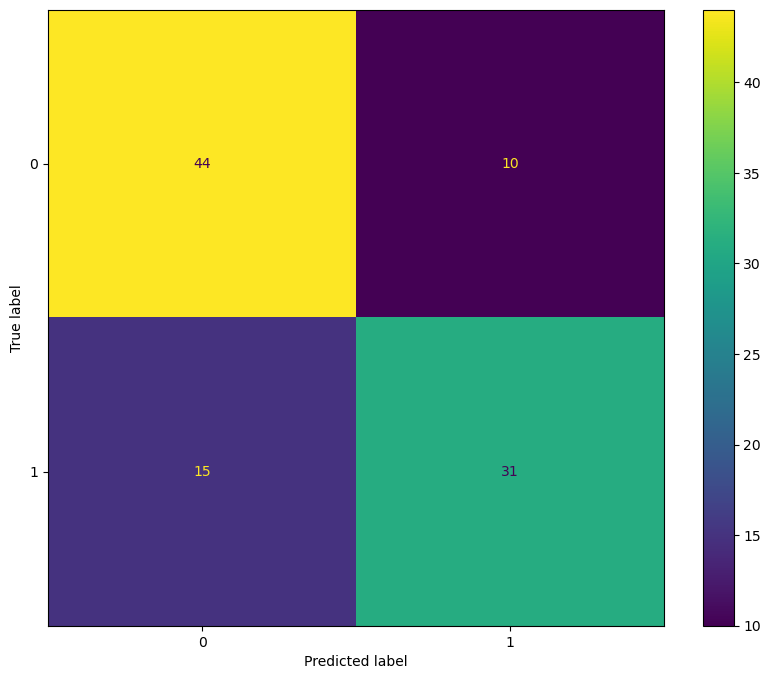

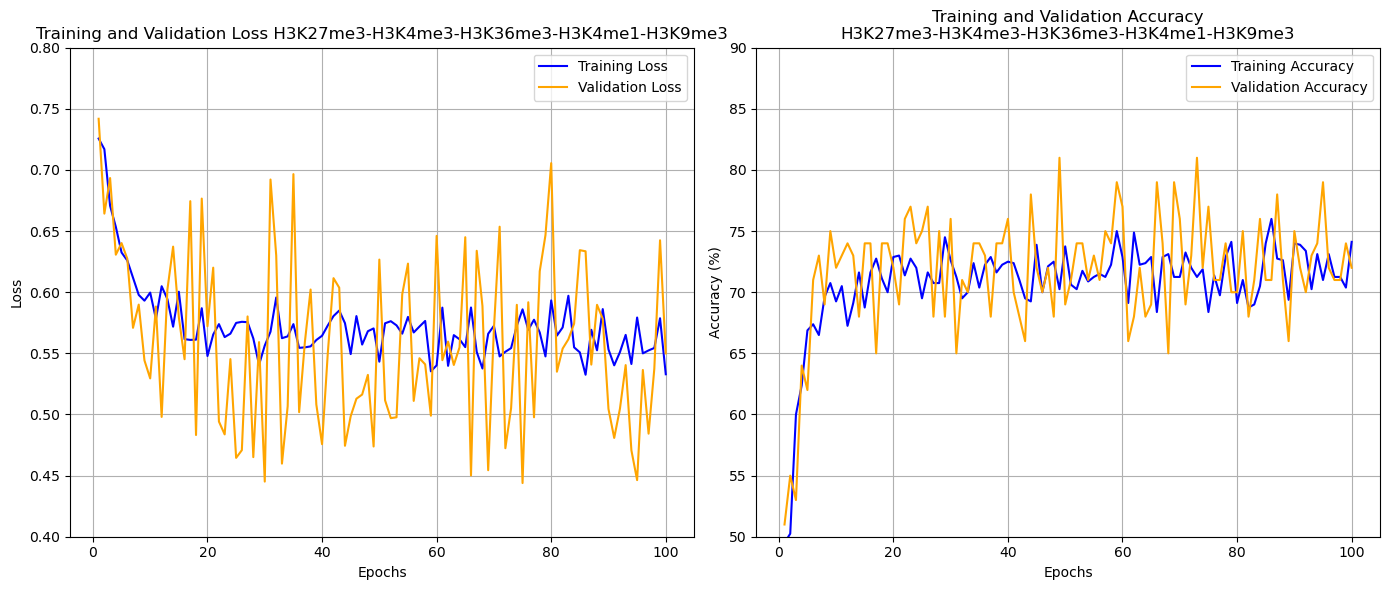

Accuracy Score on test set: 70.00 %
    AUC Score on test set: 0.70
    Precision: 0.6531
    Recall: 0.7111
    F1-Score: 0.6809

    Detailed Classification Report:
                  precision    recall  f1-score   support

           0       0.75      0.69      0.72        55
           1       0.65      0.71      0.68        45

    accuracy                           0.70       100
   macro avg       0.70      0.70      0.70       100
weighted avg       0.70      0.70      0.70       100


    Confusion Matrix:
    [[38 17]
 [13 32]]
    


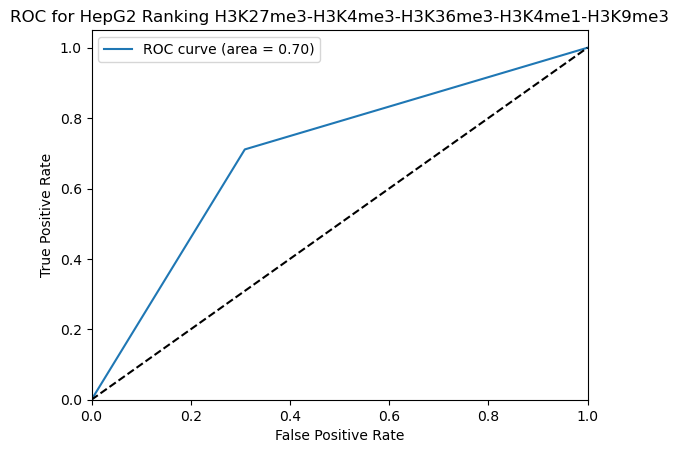

004-H3K27me3-H3K4me3-H3K36me3-H3K9me3-H3K4me1
Epoch [1/100] - [TRAIN] Loss: 0.7220, Accuracy: 48.00%, AUC: 0.48 [VAL] Loss: 0.6830, Accuracy: 61.00%, Precision: 0.61, Recall: 0.57, F1-Score: 0.59, AUC: 0.61
Epoch [2/100] - [TRAIN] Loss: 0.6877, Accuracy: 53.75%, AUC: 0.54 [VAL] Loss: 0.6580, Accuracy: 73.00%, Precision: 0.70, Recall: 0.68, F1-Score: 0.69, AUC: 0.72
Epoch [3/100] - [TRAIN] Loss: 0.6602, Accuracy: 61.88%, AUC: 0.62 [VAL] Loss: 0.6327, Accuracy: 66.00%, Precision: 0.71, Recall: 0.60, F1-Score: 0.65, AUC: 0.66
Epoch [4/100] - [TRAIN] Loss: 0.6565, Accuracy: 63.12%, AUC: 0.63 [VAL] Loss: 0.6501, Accuracy: 69.00%, Precision: 0.64, Recall: 0.65, F1-Score: 0.64, AUC: 0.69
Epoch [5/100] - [TRAIN] Loss: 0.6310, Accuracy: 67.88%, AUC: 0.68 [VAL] Loss: 0.6539, Accuracy: 66.00%, Precision: 0.64, Recall: 0.62, F1-Score: 0.63, AUC: 0.66
Epoch [6/100] - [TRAIN] Loss: 0.6276, Accuracy: 68.50%, AUC: 0.68 [VAL] Loss: 0.6040, Accuracy: 75.00%, Precision: 0.74, Recall: 0.70, F1-Score: 0.72

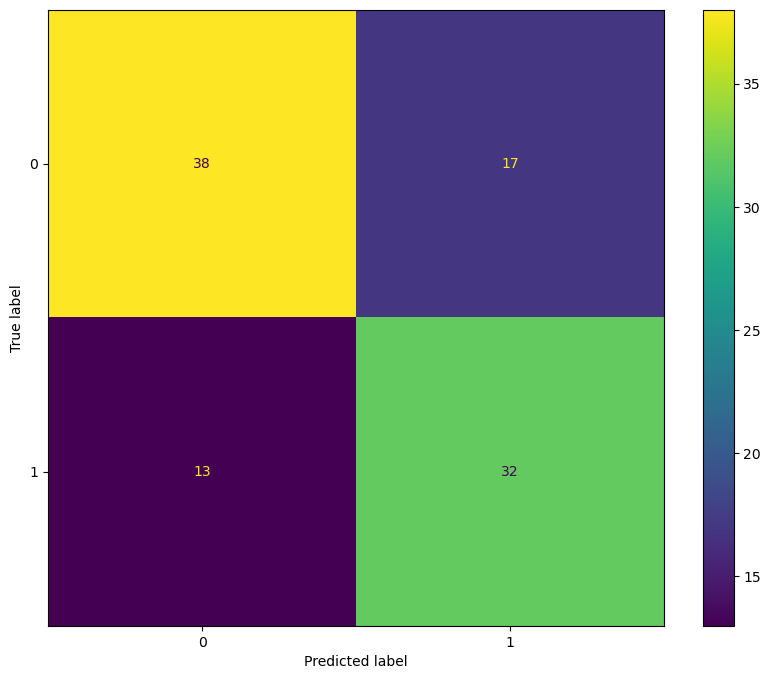

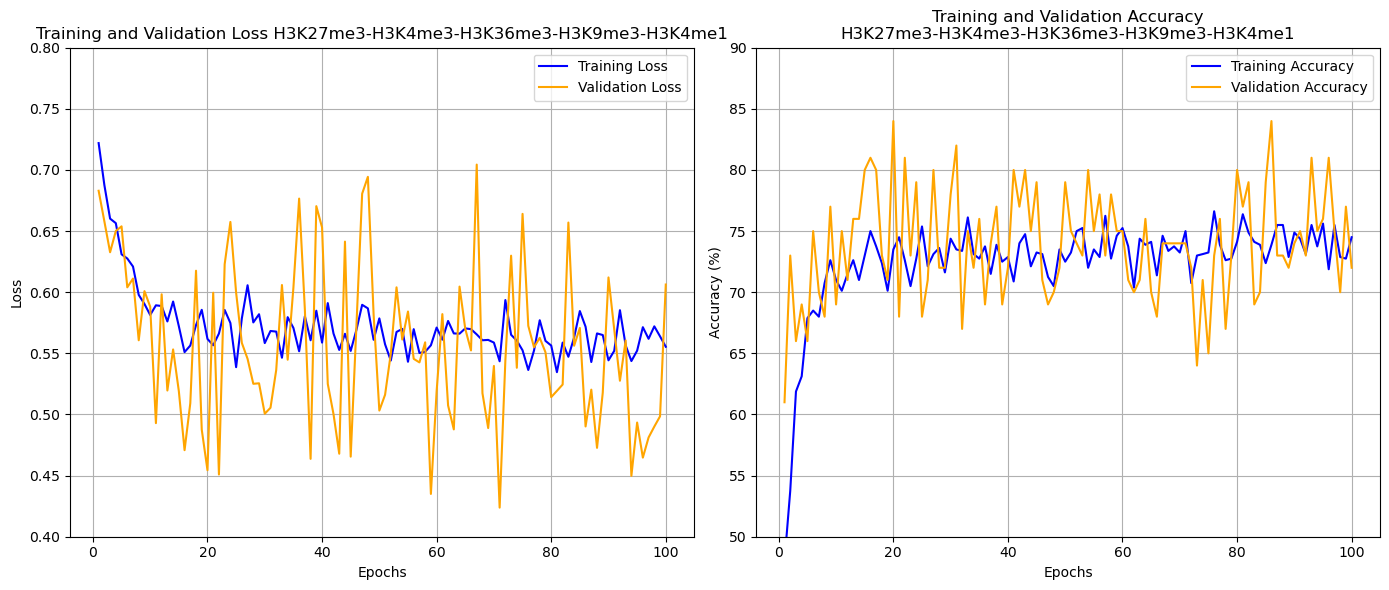

Accuracy Score on test set: 70.00 %
    AUC Score on test set: 0.70
    Precision: 0.6909
    Recall: 0.7451
    F1-Score: 0.7170

    Detailed Classification Report:
                  precision    recall  f1-score   support

           0       0.71      0.65      0.68        49
           1       0.69      0.75      0.72        51

    accuracy                           0.70       100
   macro avg       0.70      0.70      0.70       100
weighted avg       0.70      0.70      0.70       100


    Confusion Matrix:
    [[32 17]
 [13 38]]
    


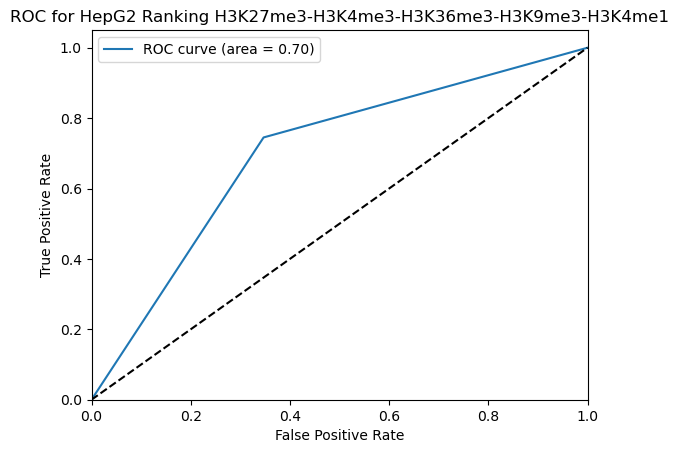

Batch FINISHED!!!


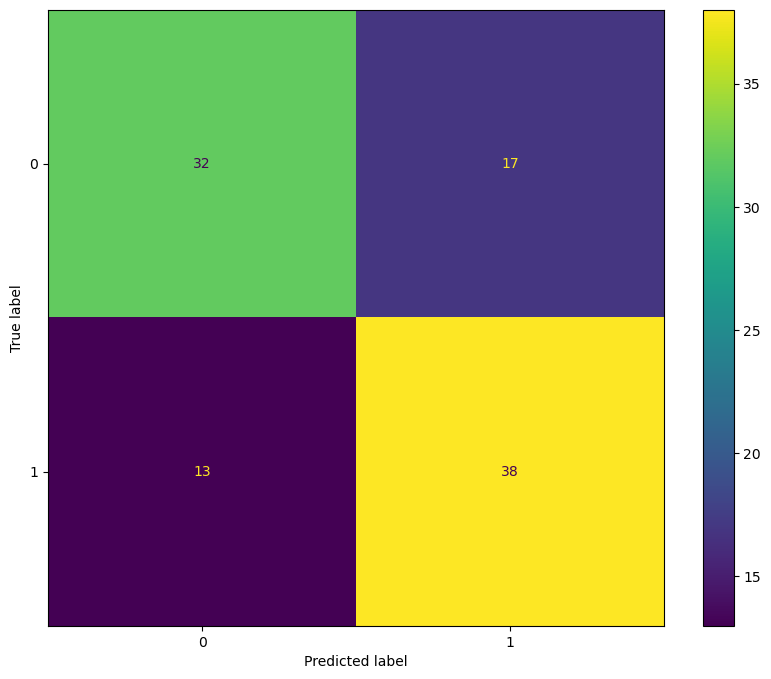

In [47]:
for number in range(START, END):
    # Building the dataframe based on histone markers
    item = working_perm[number]
    ITEM_NAME = '-'.join(item)
    FILE_NUMBER = format_file_number(number)
    print(f"{FILE_NUMBER}-{ITEM_NAME}")

    histone_df = data_df.with_columns(histone=pl.concat_list(item))
    X = histone_df["gene_id", "histone", "E066"]
    X_np = X.to_numpy()

    # Setup the experiment variable
    NUM_ITEMS = 1000
    BATCH_SIZE = 32
    INPUT_SIZE = len(X_np[0][1]) * 2 # Two histone marker data from two gene IDs
    NUM_EPOCHS = 100
    START_EPOCH = 0
    DROPOUT_RATE = 0.3
    L1_lambda = 0.005
    L2_lambda = 0.001

    # Setup the data
    train_dataset = E066Dataset(int(0.8 * NUM_ITEMS), X_np, train_idx)
    val_dataset = E066Dataset(int(0.1 * NUM_ITEMS), X_np, val_idx)
    test_dataset = E066Dataset(int(0.1 * NUM_ITEMS), X_np, test_idx)

    # Define the dataloader
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)

    # Define classifier model
    model = BC.BinaryClassifierDropOutL1L2(input_size=INPUT_SIZE).to(device)

    # Define loss function for binary classification
    criterion = nn.BCELoss()  # Binary Cross Entropy Loss

    # Training loop example
    # optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    optimizer = optim.SGD(model.parameters(), lr=0.0001, momentum=0.9)

    # Define learning rate scheduler
    scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.1)

    # Arrays for saving the performance metric
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    train_aucs, val_aucs = [], []
    val_precisions = []
    val_recalls = []
    val_f1_scores = []

    # Setup filename
    IMAGE_FILE = os.path.join(WORKING_DIR, 'output', 'img', 'train', f"{FILE_NUMBER}-{ITEM_NAME}-ranking.png")
    TEST_FILE = os.path.join(WORKING_DIR, 'output', 'test', "output", f"{FILE_NUMBER}-{ITEM_NAME}-test-results.txt")
    TRAINING_FILE = os.path.join(WORKING_DIR, 'output', 'train', f"{FILE_NUMBER}-{ITEM_NAME}-train-validation-metrics.csv")
    TEST_RESULT_FILE = os.path.join(WORKING_DIR, 'output', 'test', "metric", f"{FILE_NUMBER}-{ITEM_NAME}-test-metrics.csv")
    ROC_FILE = os.path.join(WORKING_DIR, 'output', 'img', 'roc', f"{FILE_NUMBER}-{ITEM_NAME}-roc.png")
    CM_FILE = os.path.join(WORKING_DIR, 'output', 'img', 'cm', f"{FILE_NUMBER}-{ITEM_NAME}-cm.png")

    # Training Phase
    # Training loop
    for epoch in range(START_EPOCH, NUM_EPOCHS):
        model.train()

        train_loss = 0
        train_correct = 0
        train_total = 0
        train_true_labels = []
        train_predicted_labels = []

        # Training phase
        for X_batch, y_batch in train_loader:
            outputs, l1_reg, l2_reg = model(X_batch.to(dtype=torch.float32).to(device))
            loss = criterion(outputs.squeeze(1), y_batch.to(dtype=torch.float32).to(device)) + l1_reg + l2_reg

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Calculate accuracy
            predictions = (outputs.squeeze(1) >= 0.5).long()

            train_loss += loss.item()
            train_correct += (predictions == y_batch.to(device)).sum().item()
            train_total += y_batch.size(0)
            
            train_true_labels.extend(y_batch.cpu().numpy())
            train_predicted_labels.extend(predictions.cpu().numpy())
        
        avg_train_loss = train_loss / len(train_loader)
        train_accuracy = 100 * train_correct / train_total
        train_auc_score = roc_auc_score(train_true_labels, train_predicted_labels)

        train_losses.append(round(avg_train_loss, 4))
        train_accuracies.append(round(train_accuracy, 2))
        train_aucs.append(round(train_auc_score, 2))

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        val_metric = 0
        val_true_labels = []
        val_predicted_labels = []

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs, l1_reg, l2_reg = model(X_batch.to(dtype=torch.float32).to(device))
                loss = criterion(outputs.squeeze(1), y_batch.to(dtype=torch.float32).to(device)) + l1_reg + l2_reg
                
                predictions = (outputs.squeeze(1) >= 0.5).long()
                
                val_loss += loss.item()
                val_correct += (predictions == y_batch.to(dtype=torch.float32).to(device)).sum().item()
                val_total += y_batch.size(0)
                val_true_labels.extend(y_batch.cpu().numpy())
                val_predicted_labels.extend(predictions.cpu().numpy())
                
            avg_val_loss = val_loss / len(val_loader)
            val_accuracy = 100 * val_correct / val_total
            val_metric = val_correct / len(val_loader)

            # Calculate precision, recall, and F1-score
            precision, recall, f1_score, _ = precision_recall_fscore_support(
                val_true_labels, 
                val_predicted_labels, 
                average='binary'  # Use macro average for multi-class classification
            )

            val_true_labels = np.array(val_true_labels)
            val_predicted_labels = np.array(val_predicted_labels)
            val_auc_score = roc_auc_score(val_true_labels, val_predicted_labels)

            val_losses.append(round(avg_val_loss, 4))
            val_accuracies.append(round(val_accuracy, 2))
            val_aucs.append(round(val_auc_score, 2))
            val_precisions.append(round(precision, 2))
            val_recalls.append(round(recall, 2))
            val_f1_scores.append(round(f1_score, 2))

        # Adjust learning rate
        scheduler.step(val_loss)

        print(f'Epoch [{epoch+1}/{NUM_EPOCHS}] - '
            f'[TRAIN] Loss: {avg_train_loss:.4f}, Accuracy: {train_accuracy:.2f}%, AUC: {train_auc_score:.2f} '
            f'[VAL] Loss: {avg_val_loss:.4f}, Accuracy: {val_accuracy:.2f}%, '
            f'Precision: {precision:.2f}, Recall: {recall:.2f}, F1-Score: {f1_score:.2f}, '
            f'AUC: {val_auc_score:.2f}')
        
        # # Save the model
        # torch.save({
        #     'epoch': epoch,
        #     'model_state_dict': model.state_dict(),
        #     'optimizer_state_dict': optimizer.state_dict(),
        #     'scheduler': scheduler.state_dict(),
        #     'train_losses': train_losses,
        #     'val_losses': val_losses,
        #     'train_accuracies': train_accuracies,
        #     'val_accuracies': val_accuracies,
        #     'train_aucs': train_aucs,
        #     'val_aucs': val_aucs,
        #     'val_precisions': val_precisions,
        #     'val_recalls': val_recalls,
        #     'val_f1_scores': val_f1_scores,
        # }, CHECKPOINT_NAME)

    # Plot training and validation metric
    my_util.plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies, ITEM_NAME, NUM_ITEMS, IMAGE_FILE)

    # Predict on test set
    test_predictions = []
    test_true_labels = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs, _, _ = model(X_batch.to(dtype=torch.float32).to(device))
            
            predictions = (outputs.squeeze(1) >= 0.5).long()
            test_true_labels.extend(y_batch.cpu().numpy())
            test_predictions.extend(predictions.cpu().numpy())

    # Evaluation metrics
    # Precision, Recall, F1-Score
    precision, recall, f1_score, _ = precision_recall_fscore_support(
        test_true_labels, 
        test_predictions, 
        average='binary'  # Use 'macro' for multi-class
    )

    test_acc_score = accuracy_score(test_true_labels, test_predictions) * 100
    test_auc_score = roc_auc_score(test_true_labels, test_predictions)
    cr = classification_report(test_true_labels, test_predictions)
    cm = confusion_matrix(test_true_labels, test_predictions)

    test_output = f"""Accuracy Score on test set: {test_acc_score:.2f} %
    AUC Score on test set: {test_auc_score:.2f}
    Precision: {precision:.4f}
    Recall: {recall:.4f}
    F1-Score: {f1_score:.4f}

    Detailed Classification Report:
    {cr}

    Confusion Matrix:
    {cm}
    """

    print(test_output)

    # Save the test output to text file
    with open(TEST_FILE, 'w', newline = '') as text_file:
        text_file.write(test_output)

    # Training metrics
    experiment_results = {
        'train_loss'    : train_losses,
        'train_accuracy': train_accuracies,
        'train_auc'     : train_aucs,
        'val_loss'      : val_losses,
        'val_accuracy'  : val_accuracies,
        'val_auc'       : val_aucs
    }

    experiment_pl = pl.DataFrame(experiment_results)
    experiment_pl.write_csv(TRAINING_FILE)

    # Get the average for each column
    experiment_mean = experiment_pl.mean()
    experiment_mean

    # Test output
    test_results = {
        'histone_marker'     : ITEM_NAME,
        'train_loss_avg'     : round(experiment_mean["train_loss"][0], 4),
        'train_accuracy_avg' : round(experiment_mean["train_accuracy"][0], 4),
        'train_auc_avg'      : round(experiment_mean["train_auc"][0], 4),
        'val_loss_avg'       : round(experiment_mean["val_loss"][0], 4),
        'val_accuracy_avg'   : round(experiment_mean["val_accuracy"][0], 4),
        'val_auc_avg'        : round(experiment_mean["val_auc"][0], 4),
        'test_acc'           : round(test_acc_score, 4),
        'test_auc'           : round(test_auc_score, 4)
    }

    test_pl = pl.DataFrame(test_results)
    test_pl.write_csv(TEST_RESULT_FILE)

    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(test_true_labels, test_predictions) 
    roc_auc = auc(fpr, tpr)

    # Plot the ROC curve
    plt.figure()  
    plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC for HepG2 Ranking {ITEM_NAME}')
    plt.legend()
    plt.savefig(ROC_FILE)
    plt.show()

    # Plot the confusion matrix
    cm_display = ConfusionMatrixDisplay(confusion_matrix=cm)
    fig, ax = plt.subplots(figsize=(10, 8))
    cm_display.plot(ax=ax)
    plt.savefig(CM_FILE)

print("Batch FINISHED!!!")